# Numerical Derivatives Using NumPy

This notebook demonstrates how to compute derivatives **numerically** using NumPy, without symbolic computation. This approach is practical for real-world applications where analytical derivatives may be difficult or impossible to compute.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Numerical Differentiation: The Big Picture

Recall the definition of the derivative:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

### Why Numerical Derivatives?

**Advantages:**
- Works for any function, even ones without closed-form derivatives
- No need to compute symbolic derivatives
- Practical for empirical functions (e.g., data from experiments or simulations)
- Used in machine learning (gradient descent) and scientific computing

**Disadvantages:**
- Approximation, not exact
- Susceptible to floating-point errors
- Requires choosing an appropriate step size $h$

### Three Main Approaches

1. **Forward Difference**: $f'(x) \approx \frac{f(x+h) - f(x)}{h}$
   - One-sided, less accurate
   - O(h) error

2. **Backward Difference**: $f'(x) \approx \frac{f(x) - f(x-h)}{h}$
   - One-sided, less accurate
   - O(h) error

3. **Central Difference**: $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$
   - Two-sided, more accurate
   - O(h²) error

## Implementation: Finite Difference Methods

Below we implement the three finite difference methods as functions.

In [10]:
def forward_difference(f, x, h=1e-5):
    """Compute derivative using forward difference method.
    
    Args:
        f: Function to differentiate
        x: Point at which to compute derivative
        h: Step size (default 1e-5)
    
    Returns:
        Approximate derivative f'(x)
    """
    return (f(x + h) - f(x)) / h

def backward_difference(f, x, h=1e-5):
    """Compute derivative using backward difference method.
    
    Args:
        f: Function to differentiate
        x: Point at which to compute derivative
        h: Step size (default 1e-5)
    
    Returns:
        Approximate derivative f'(x)
    """
    return (f(x) - f(x - h)) / h

def central_difference(f, x, h=1e-5):
    """Compute derivative using central difference method.
    
    Args:
        f: Function to differentiate
        x: Point at which to compute derivative
        h: Step size (default 1e-5)
    
    Returns:
        Approximate derivative f'(x)
    """
    return (f(x + h) - f(x - h)) / (2 * h)

print("Finite difference methods implemented successfully!")

Finite difference methods implemented successfully!


## Example 1: Derivative of f(x) = x²

**Analytical derivative**: $f'(x) = 2x$

Let's compare all three numerical methods at x = 3 (analytical: f'(3) = 6)

In [11]:
# Define the function and its analytical derivative
def f_quad(x):
    return x**2

def f_quad_prime(x):
    """Analytical derivative: f'(x) = 2x"""
    return 2 * x

# Test point
x_test = 3.0
h_values = [1e-3, 1e-5, 1e-7, 1e-9]

print("="*70)
print(f"f(x) = x²,  at x = {x_test}")
print(f"Analytical derivative: f'({x_test}) = {f_quad_prime(x_test)}")
print("="*70)

for h in h_values:
    forward = forward_difference(f_quad, x_test, h)
    backward = backward_difference(f_quad, x_test, h)
    central = central_difference(f_quad, x_test, h)
    
    print(f"\nh = {h}:")
    print(f"  Forward:  {forward:.12f}  (error: {abs(forward - f_quad_prime(x_test)):.2e})")
    print(f"  Backward: {backward:.12f}  (error: {abs(backward - f_quad_prime(x_test)):.2e})")
    print(f"  Central:  {central:.12f}  (error: {abs(central - f_quad_prime(x_test)):.2e})")

f(x) = x²,  at x = 3.0
Analytical derivative: f'(3.0) = 6.0

h = 0.001:
  Forward:  6.000999999999  (error: 1.00e-03)
  Backward: 5.998999999999  (error: 1.00e-03)
  Central:  5.999999999999  (error: 6.61e-13)

h = 1e-05:
  Forward:  6.000009999951  (error: 1.00e-05)
  Backward: 5.999990000127  (error: 1.00e-05)
  Central:  6.000000000039  (error: 3.93e-11)

h = 1e-07:
  Forward:  6.000000087880  (error: 8.79e-08)
  Backward: 5.999999892481  (error: 1.08e-07)
  Central:  5.999999990181  (error: 9.82e-09)

h = 1e-09:
  Forward:  6.000000496442  (error: 4.96e-07)
  Backward: 6.000000496442  (error: 4.96e-07)
  Central:  6.000000496442  (error: 4.96e-07)


## Example 2: Derivative of f(x) = sin(x)

**Analytical derivative**: $f'(x) = \cos(x)$

Let's test at x = π/4 (analytical: f'(π/4) ≈ 0.7071)

In [12]:
# Define the function and its analytical derivative
def f_sin(x):
    return np.sin(x)

def f_sin_prime(x):
    """Analytical derivative: f'(x) = cos(x)"""
    return np.cos(x)

# Test point
x_test = np.pi / 4
analytical = f_sin_prime(x_test)

print("="*70)
print(f"f(x) = sin(x),  at x = π/4 ≈ {x_test:.6f}")
print(f"Analytical derivative: f'(π/4) = cos(π/4) ≈ {analytical:.12f}")
print("="*70)

for h in h_values:
    forward = forward_difference(f_sin, x_test, h)
    backward = backward_difference(f_sin, x_test, h)
    central = central_difference(f_sin, x_test, h)
    
    print(f"\nh = {h}:")
    print(f"  Forward:  {forward:.12f}  (error: {abs(forward - analytical):.2e})")
    print(f"  Backward: {backward:.12f}  (error: {abs(backward - analytical):.2e})")
    print(f"  Central:  {central:.12f}  (error: {abs(central - analytical):.2e})")

f(x) = sin(x),  at x = π/4 ≈ 0.785398
Analytical derivative: f'(π/4) = cos(π/4) ≈ 0.707106781187

h = 0.001:
  Forward:  0.706753109974  (error: 3.54e-04)
  Backward: 0.707460216697  (error: 3.53e-04)
  Central:  0.707106663335  (error: 1.18e-07)

h = 1e-05:
  Forward:  0.707103245645  (error: 3.54e-06)
  Backward: 0.707110316700  (error: 3.54e-06)
  Central:  0.707106781173  (error: 1.40e-11)

h = 1e-07:
  Forward:  0.707106745379  (error: 3.58e-08)
  Backward: 0.707106815323  (error: 3.41e-08)
  Central:  0.707106780351  (error: 8.36e-10)

h = 1e-09:
  Forward:  0.707106817543  (error: 3.64e-08)
  Backward: 0.707106706521  (error: 7.47e-08)
  Central:  0.707106762032  (error: 1.92e-08)


## Vectorized Numerical Derivatives

For computing derivatives at multiple points, we can use NumPy's vectorization to evaluate all points efficiently.

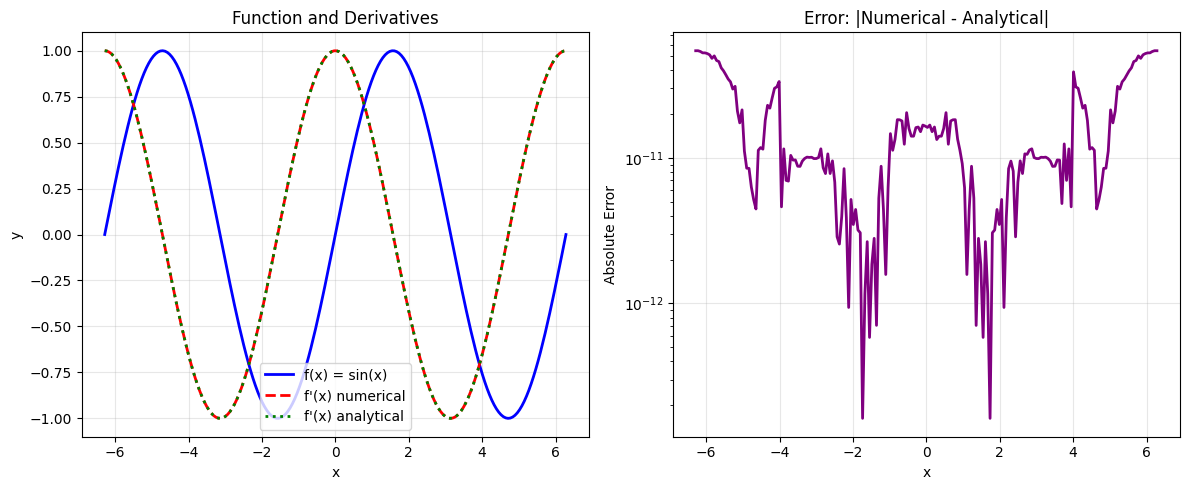

Max absolute error: 5.45e-11
Mean absolute error: 1.69e-11


In [13]:
def numerical_derivative_array(f, x_array, h=1e-5, method='central'):
    """Compute derivatives at multiple points using NumPy vectorization.
    
    Args:
        f: Function to differentiate
        x_array: Array of points at which to compute derivative
        h: Step size
        method: 'forward', 'backward', or 'central'
    
    Returns:
        Array of approximate derivatives
    """
    if method == 'forward':
        return (f(x_array + h) - f(x_array)) / h
    elif method == 'backward':
        return (f(x_array) - f(x_array - h)) / h
    elif method == 'central':
        return (f(x_array + h) - f(x_array - h)) / (2 * h)
    else:
        raise ValueError("method must be 'forward', 'backward', or 'central'")

# Generate x values
x = np.linspace(-2*np.pi, 2*np.pi, 200)

# Define test function: f(x) = sin(x), f'(x) = cos(x)
def f(x):
    return np.sin(x)

def f_analytical(x):
    return np.cos(x)

# Compute numerical derivatives
f_prime_numerical = numerical_derivative_array(f, x, h=1e-5, method='central')
f_prime_analytical = f_analytical(x)

# Plot comparison
plt.figure(figsize=(12, 5))

# Plot 1: Function and its derivative
plt.subplot(1, 2, 1)
plt.plot(x, f(x), 'b-', label='f(x) = sin(x)', linewidth=2)
plt.plot(x, f_prime_numerical, 'r--', label="f'(x) numerical", linewidth=2)
plt.plot(x, f_prime_analytical, 'g:', label="f'(x) analytical", linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function and Derivatives')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error between numerical and analytical
plt.subplot(1, 2, 2)
error = np.abs(f_prime_numerical - f_prime_analytical)
plt.plot(x, error, 'purple', linewidth=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Error: |Numerical - Analytical|')
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

print(f"Max absolute error: {np.max(error):.2e}")
print(f"Mean absolute error: {np.mean(error):.2e}")

## Effect of Step Size on Accuracy

One critical aspect of numerical differentiation is choosing an appropriate step size $h$. Too large, and the approximation is inaccurate. Too small, and floating-point errors dominate.

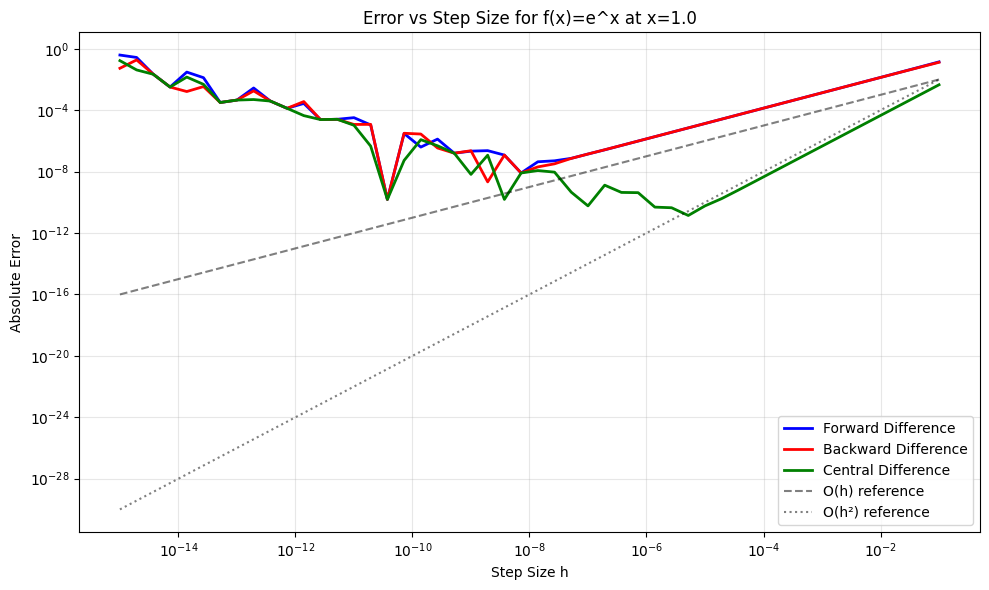


Observations:
- Forward and backward difference: O(h) error (linear decrease)
- Central difference: O(h²) error (quadratic decrease)
- At very small h, floating-point errors dominate (error increases)
- Optimal h typically around 1e-5 to 1e-8


In [14]:
# Test the effect of step size
def f_exp(x):
    """f(x) = e^x"""
    return np.exp(x)

def f_exp_prime(x):
    """f'(x) = e^x"""
    return np.exp(x)

x_test = 1.0
analytical_value = f_exp_prime(x_test)

# Test many different step sizes
h_range = np.logspace(-15, -1, 50)  # h from 1e-15 to 1e-1
errors_forward = []
errors_backward = []
errors_central = []

for h in h_range:
    forward = forward_difference(f_exp, x_test, h)
    backward = backward_difference(f_exp, x_test, h)
    central = central_difference(f_exp, x_test, h)
    
    errors_forward.append(abs(forward - analytical_value))
    errors_backward.append(abs(backward - analytical_value))
    errors_central.append(abs(central - analytical_value))

# Plot error vs step size
plt.figure(figsize=(10, 6))
plt.loglog(h_range, errors_forward, 'b-', label='Forward Difference', linewidth=2)
plt.loglog(h_range, errors_backward, 'r-', label='Backward Difference', linewidth=2)
plt.loglog(h_range, errors_central, 'g-', label='Central Difference', linewidth=2)
plt.xlabel('Step Size h')
plt.ylabel('Absolute Error')
plt.title(f"Error vs Step Size for f(x)=e^x at x={x_test}")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')

# Add reference lines for O(h) and O(h²) convergence
plt.loglog(h_range, h_range * 1e-1, 'k--', alpha=0.5, label='O(h) reference')
plt.loglog(h_range, h_range**2 * 1e0, 'k:', alpha=0.5, label='O(h²) reference')
plt.legend()

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Forward and backward difference: O(h) error (linear decrease)")
print("- Central difference: O(h²) error (quadratic decrease)")
print("- At very small h, floating-point errors dominate (error increases)")
print("- Optimal h typically around 1e-5 to 1e-8")

## Using NumPy's gradient() Function

NumPy provides a built-in `gradient()` function for computing numerical derivatives of arrays.

### How np.gradient() Works

`np.gradient()` computes the gradient (derivative) of an array using **finite differences**. Here's how it works:

**Syntax:**
```python
np.gradient(f_array, x_spacing)
```

**Parameters:**
- `f_array`: Array of function values y = f(x)
- `x_spacing`: Spacing between points (distance between consecutive x values)

**Algorithm:**
- **Interior points** (not at edges): Uses **central difference** for accuracy
  $$\frac{df}{dx}\bigg|_{i} = \frac{f_{i+1} - f_{i-1}}{2h}$$
  
- **First point** (left edge): Uses **forward difference**
  $$\frac{df}{dx}\bigg|_0 = \frac{f_1 - f_0}{h}$$
  
- **Last point** (right edge): Uses **backward difference**
  $$\frac{df}{dx}\bigg|_n = \frac{f_n - f_{n-1}}{h}$$

where $h$ is the spacing between consecutive points.

**Why is central difference used?**
- More accurate than forward/backward (O(h²) error vs O(h))
- Smoothly approximates the true derivative
- Works well for uniformly spaced data

**Example with manual calculation:**
For array `y = [1, 4, 9, 16, 25]` (representing f(x) = x² at x = [1, 2, 3, 4, 5]):
- Point 0: gradient = (4 - 1) / (2 - 1) = 3
- Point 1: gradient = (9 - 1) / (3 - 1) = 4
- Point 2: gradient = (16 - 4) / (4 - 2) = 6 (central)
- Point 3: gradient = (25 - 9) / (5 - 3) = 8
- Point 4: gradient = (25 - 16) / (5 - 4) = 9

This matches the analytical derivative f'(x) = 2x: [2, 4, 6, 8, 10] at x = [1, 2, 3, 4, 5].

==> x:
[0.         0.06346652 0.12693304 0.19039955 0.25386607 0.31733259
 0.38079911 0.44426563 0.50773215 0.57119866 0.63466518 0.6981317
 0.76159822 0.82506474 0.88853126 0.95199777 1.01546429 1.07893081
 1.14239733 1.20586385 1.26933037 1.33279688 1.3962634  1.45972992
 1.52319644 1.58666296 1.65012947 1.71359599 1.77706251 1.84052903
 1.90399555 1.96746207 2.03092858 2.0943951  2.15786162 2.22132814
 2.28479466 2.34826118 2.41172769 2.47519421 2.53866073 2.60212725
 2.66559377 2.72906028 2.7925268  2.85599332 2.91945984 2.98292636
 3.04639288 3.10985939 3.17332591 3.23679243 3.30025895 3.36372547
 3.42719199 3.4906585  3.55412502 3.61759154 3.68105806 3.74452458
 3.8079911  3.87145761 3.93492413 3.99839065 4.06185717 4.12532369
 4.1887902  4.25225672 4.31572324 4.37918976 4.44265628 4.5061228
 4.56958931 4.63305583 4.69652235 4.75998887 4.82345539 4.88692191
 4.95038842 5.01385494 5.07732146 5.14078798 5.2042545  5.26772102
 5.33118753 5.39465405 5.45812057 5.52158709 5.58505361 5

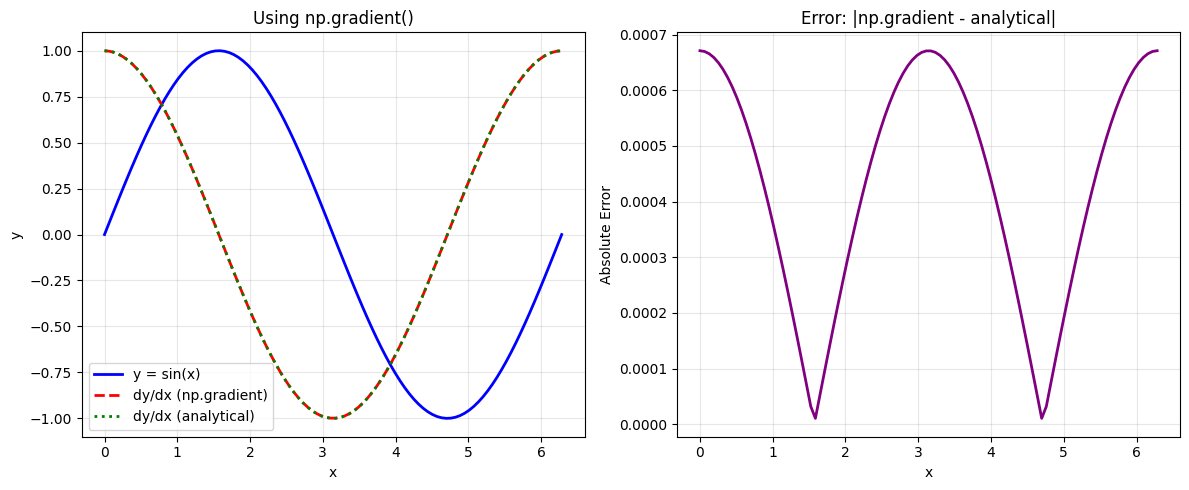

Max error: 6.711980e-04
Mean error: 4.297546e-04

np.gradient() uses central differences, making it more accurate than forward/backward methods.


In [15]:
# Generate data: x values and corresponding y values
x = np.linspace(0, 2*np.pi, 100)
print("==> x:")
print(x)
y = np.sin(x)
print("==> y:")
print(y)
# Compute numerical derivative using np.gradient
dy_dx = np.gradient(y, x)
print("==> dy_dx:")
print(dy_dx)

# Analytical derivative: cos(x)
dy_dx_analytical = np.cos(x)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, y, 'b-', label='y = sin(x)', linewidth=2)
plt.plot(x, dy_dx, 'r--', label="dy/dx (np.gradient)", linewidth=2)
plt.plot(x, dy_dx_analytical, 'g:', label="dy/dx (analytical)", linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Using np.gradient()')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
error = np.abs(dy_dx - dy_dx_analytical)
plt.plot(x, error, 'purple', linewidth=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Error: |np.gradient - analytical|')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max error: {np.max(error):.6e}")
print(f"Mean error: {np.mean(error):.6e}")
print("\nnp.gradient() uses central differences, making it more accurate than forward/backward methods.")

## Summary: Numerical vs Symbolic Derivatives

| Aspect | Numerical (NumPy) | Symbolic (SymPy) |
|--------|-------------------|------------------|
| **Accuracy** | Approximate (O(h) to O(h²)) | Exact |
| **Computation** | Fast for arrays, embarrassingly parallel | Can be slow for complex expressions |
| **Domains** | Empirical functions, any callable | Algebraic expressions |
| **Step size** | Must choose $h$ carefully | No step size parameter |
| **Floating-point errors** | Can accumulate | Not affected |
| **Machine learning** | Essential (gradient descent) | Rarely used |

### When to Use Each:

**Use Numerical Derivatives:**
- Machine learning (gradient descent, backpropagation)
- Empirical data or experimental measurements
- Complex functions without closed forms
- When speed is critical for large datasets

**Use Symbolic Derivatives:**
- Mathematical analysis and proofs
- Understanding derivative behavior
- Exact solutions needed
- Educational purposes